## ZOMATO PROJECT

In [1]:
pip install pandas matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Import libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("zomato.csv")
df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


## MOST EXPENSIVE RESTAURANTS

In [6]:
import pandas as pd

df = pd.read_csv("zomato.csv")

df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '')
)

df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)


expensive_restaurants = df[['name', 'location', 'approx_cost(for two people)']]

expensive_restaurants = expensive_restaurants.sort_values(
    by='approx_cost(for two people)',
    ascending=False
).head(10)

print(expensive_restaurants)

                                         name          location  \
49482  Le Cirque Signature - The Leela Palace  Old Airport Road   
20404  Le Cirque Signature - The Leela Palace  Old Airport Road   
43481              Royal Afghan - ITC Windsor       Sankey Road   
44933                  Malties - Radisson Blu      Marathahalli   
45523                  Malties - Radisson Blu      Marathahalli   
43477              La Brasserie - Le Meridien       Sankey Road   
42581              La Brasserie - Le Meridien       Sankey Road   
42245              La Brasserie - Le Meridien       Sankey Road   
40641              La Brasserie - Le Meridien       Sankey Road   
13913          Masala Klub - The Taj West End  Race Course Road   

       approx_cost(for two people)  
49482                       6000.0  
20404                       6000.0  
43481                       5000.0  
44933                       4500.0  
45523                       4500.0  
43477                       4100.0  
425

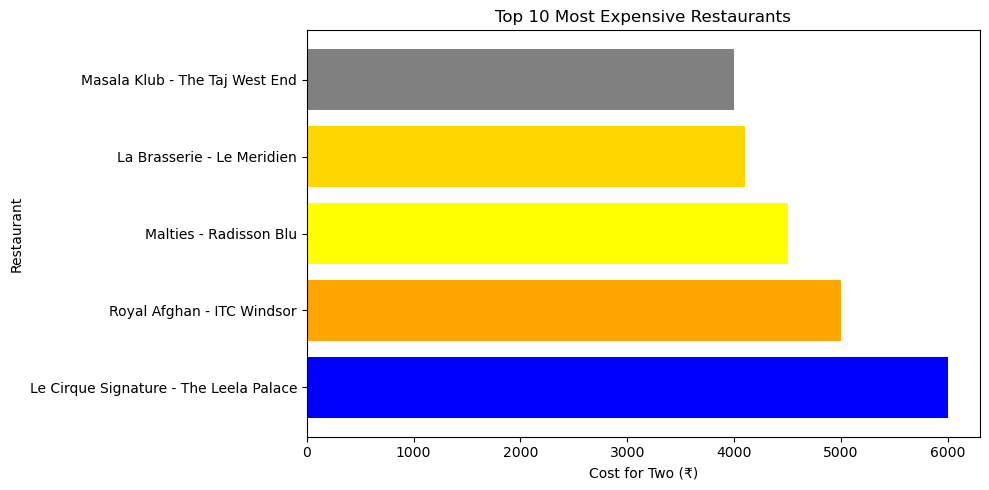

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("zomato.csv")

df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '')
)

df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)

top10 = df[['name', 'approx_cost(for two people)']].dropna()

top10 = top10.sort_values(
    by='approx_cost(for two people)',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

colors = ['purple','blue','orange','lightgreen','yellow',
          'pink','cyan','red','gold','gray']

plt.barh(top10['name'],
         top10['approx_cost(for two people)'],
         color=colors)

plt.title('Top 10 Most Expensive Restaurants')
plt.xlabel('Cost for Two (₹)')
plt.ylabel('Restaurant')

plt.tight_layout()
plt.show()

## MOST POPULAR CUISINES

In [8]:
import pandas as pd

# Load dataset
df = pd.read_csv("zomato.csv")

# Split cuisines and count individually
all_cuisines = df['cuisines'].dropna().str.split(', ')

cuisine_count = {}

for cuisine_list in all_cuisines:
    for cuisine in cuisine_list:
        cuisine_count[cuisine] = cuisine_count.get(cuisine, 0) + 1

top_10 = sorted(cuisine_count.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 Most Popular Cuisines:")
for cuisine, count in top_10:
    print(f"{cuisine}: {count}")

Top 10 Most Popular Cuisines:
North Indian: 21085
Chinese: 15547
South Indian: 8644
Fast Food: 8096
Biryani: 6492
Continental: 5765
Desserts: 5633
Cafe: 5303
Beverages: 4747
Italian: 3389


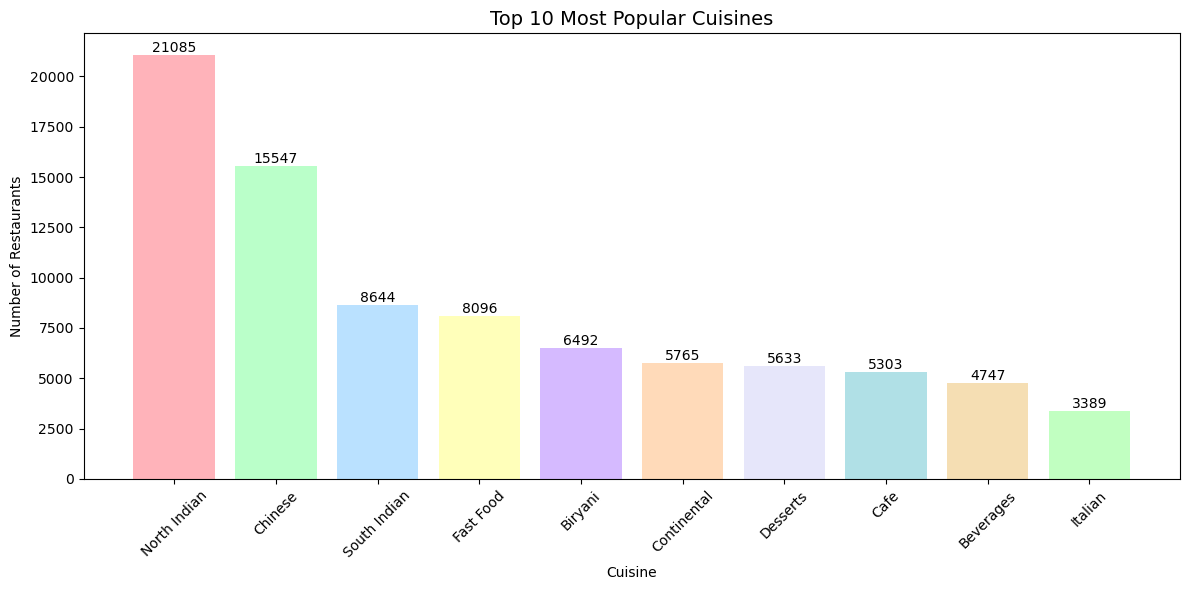

In [9]:
import matplotlib.pyplot as plt

cuisines = [x[0] for x in top_10]
counts = [x[1] for x in top_10]

colors = [
    '#FFB3BA',  
    '#BAFFC9',   
    '#BAE1FF', 
    '#FFFFBA',  
    '#D5BAFF',  
    '#FFDAB9',
    '#E6E6FA',  
    '#B0E0E6',
    '#F5DEB3',
    '#C1FFC1'   
]

plt.figure(figsize=(12,6))
bars = plt.bar(cuisines, counts, color=colors)

plt.title("Top 10 Most Popular Cuisines", fontsize=14)
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             str(int(height)),
             ha='center',
             va='bottom')

plt.tight_layout()
plt.show()

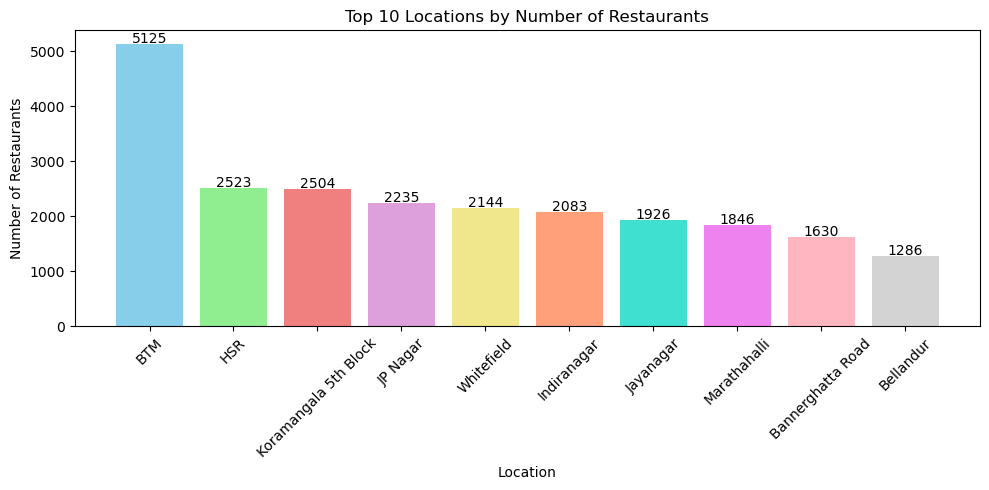

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("zomato.csv")


top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(top_locations.index,
        top_locations.values,
        color=['skyblue','lightgreen','lightcoral','plum','khaki',
               'lightsalmon','turquoise','violet','lightpink','lightgray'])

plt.title("Top 10 Locations by Number of Restaurants")
plt.xlabel("Location")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)

for i, v in enumerate(top_locations.values):
    plt.text(i, v + 20, str(v), ha='center')

plt.tight_layout()
plt.show()

## AVERAGE CUSTOMER RATING

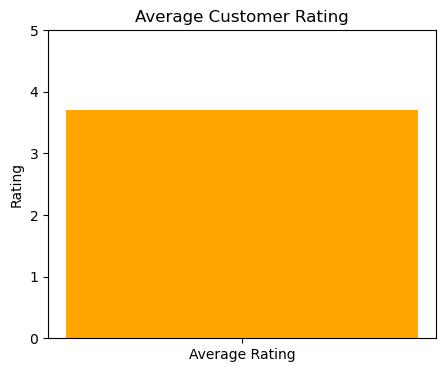

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("zomato.csv")

df['rate'] = df['rate'].astype(str).str.split('/').str[0]
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

average_rating = df['rate'].mean()

plt.figure(figsize=(5,4))
plt.bar(['Average Rating'], [average_rating], color='orange')
plt.ylabel('Rating')
plt.title('Average Customer Rating')
plt.ylim(0, 5)
plt.show()

## HIGHEST RATED RESTAURANTS

In [12]:
import pandas as pd

df = pd.read_csv("zomato.csv")

df['rate'] = df['rate'].astype(str).str.split('/').str[0]
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')


top_5_threshold = df['rate'].quantile(0.95)

top_5_percent = df[df['rate'] >= top_5_threshold]

print("95th Percentile Rating:", top_5_threshold)
print("Number of Restaurants in Top 5%:", len(top_5_percent))


print(top_5_percent[['name', 'location', 'rate']].sort_values(by='rate', ascending=False).head(10))

95th Percentile Rating: 4.4
Number of Restaurants in Top 5%: 2391
                                 name               location  rate
34427  Asia Kitchen By Mainland China  Koramangala 5th Block   4.9
53995     Byg Brewski Brewing Company          Sarjapur Road   4.9
39480  Asia Kitchen By Mainland China  Koramangala 5th Block   4.9
45826          Belgian Waffle Factory           Brigade Road   4.9
13155          Belgian Waffle Factory           Brigade Road   4.9
51511          Belgian Waffle Factory           Brigade Road   4.9
10897          Belgian Waffle Factory  Koramangala 5th Block   4.9
5405           Belgian Waffle Factory           Brigade Road   4.9
52154          Belgian Waffle Factory           Brigade Road   4.9
7564                     Punjab Grill             Whitefield   4.9


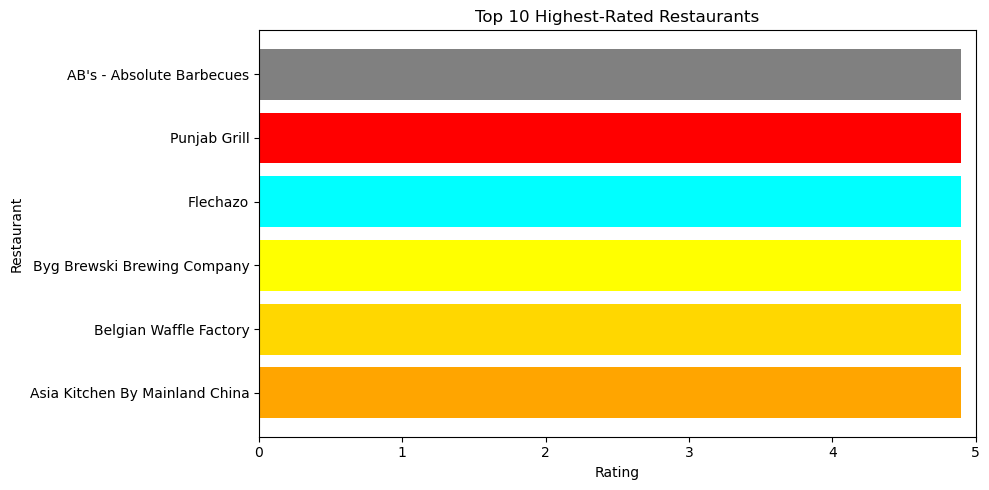

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("zomato.csv")

df['rate'] = df['rate'].astype(str).str.split('/').str[0]
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

top_restaurants = df[['name', 'rate']].dropna()
top_restaurants = top_restaurants.sort_values(by='rate', ascending=False).head(10)

colors = ['purple', 'blue', 'orange', 'lightgreen', 'yellow',
          'pink', 'cyan', 'red', 'gold', 'gray']

plt.figure(figsize=(10,5))
plt.barh(top_restaurants['name'],
         top_restaurants['rate'],
         color=colors)

plt.xlabel('Rating')
plt.ylabel('Restaurant')
plt.title('Top 10 Highest-Rated Restaurants')
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

## VOTES AND RATING

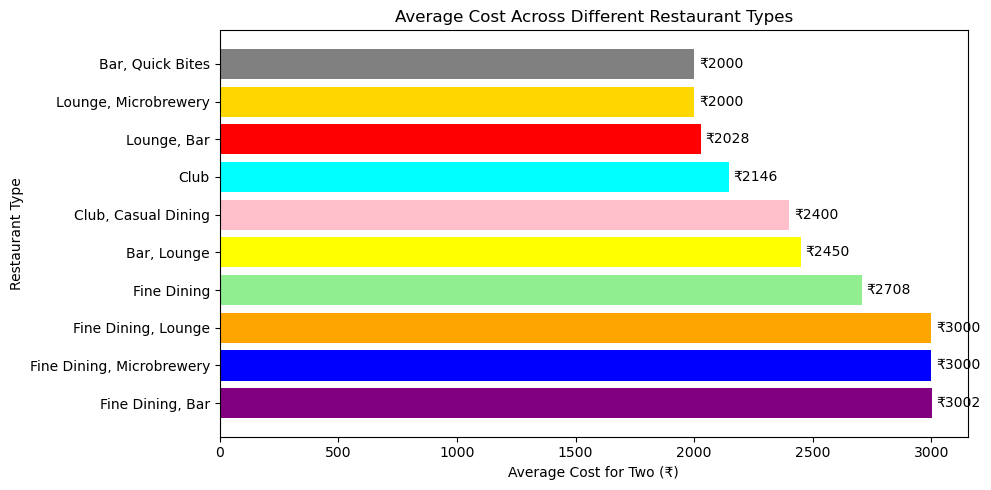

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("zomato.csv")


df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '')
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')


cost_analysis = df.groupby('rest_type')['approx_cost(for two people)'].mean()

top_cost = cost_analysis.sort_values(ascending=False).head(10)

colors = ['purple', 'blue', 'orange', 'lightgreen', 'yellow',
          'pink', 'cyan', 'red', 'gold', 'gray']

plt.figure(figsize=(10,5))
plt.barh(top_cost.index, top_cost.values, color=colors)

plt.xlabel('Average Cost for Two (₹)')
plt.ylabel('Restaurant Type')
plt.title('Average Cost Across Different Restaurant Types')

for i, v in enumerate(top_cost.values):
    plt.text(v + 20, i, f'₹{v:.0f}', va='center')

plt.tight_layout()
plt.show()


## Premium vs budget restuarant analysis

               rate  approx_cost(for two people)
Category                                        
Budget     3.582490                   323.854971
Mid-Range  3.839243                   856.601263
Premium    4.102398                  2126.981450


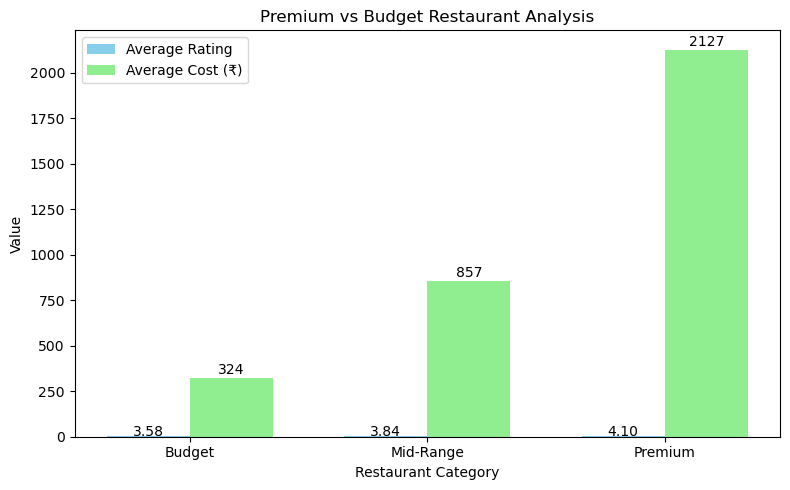

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("zomato.csv")


df['rate'] = df['rate'].astype(str).str.split('/').str[0]
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')


df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '', regex=False)
)
df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)


def category(cost):
    if cost <= 500:
        return 'Budget'
    elif cost <= 1500:
        return 'Mid-Range'
    else:
        return 'Premium'

df['Category'] = df['approx_cost(for two people)'].apply(category)


analysis = df.groupby('Category')[['rate', 'approx_cost(for two people)']].mean()

print(analysis)

x = np.arange(len(analysis.index))
width = 0.35

plt.figure(figsize=(8,5))


plt.bar(x - width/2,
        analysis['rate'],
        width,
        label='Average Rating',
        color='skyblue')

plt.bar(x + width/2,
        analysis['approx_cost(for two people)'],
        width,
        label='Average Cost (₹)',
        color='lightgreen')

plt.xticks(x, analysis.index)
plt.xlabel("Restaurant Category")
plt.ylabel("Value")
plt.title("Premium vs Budget Restaurant Analysis")
plt.legend()


for i, value in enumerate(analysis['rate']):
    plt.text(i - width/2, value + 0.05, f"{value:.2f}", ha='center')

for i, value in enumerate(analysis['approx_cost(for two people)']):
    plt.text(i + width/2, value + 20, f"{value:.0f}", ha='center')

plt.tight_layout()
plt.show()

## Average votes vs Rating

                    votes      rate
Rating_Group                       
0-2            325.875000  1.937500
2-3             99.367034  2.826317
3-4            136.169495  3.621434
4-5           1123.062826  4.263184


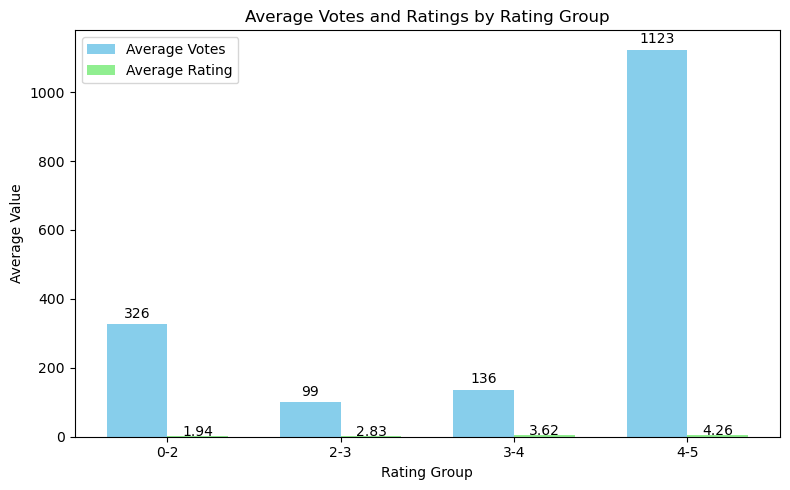

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("zomato.csv")

df['rate'] = df['rate'].astype(str).str.split('/').str[0]
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')


df['votes'] = pd.to_numeric(df['votes'], errors='coerce')


bins = [0, 2, 3, 4, 5]
labels = ['0-2', '2-3', '3-4', '4-5']
df['Rating_Group'] = pd.cut(df['rate'], bins=bins, labels=labels)


analysis = df.groupby('Rating_Group', observed=False)[['votes', 'rate']].mean()

print(analysis)


x = np.arange(len(analysis.index))
width = 0.35

plt.figure(figsize=(8,5))


plt.bar(x - width/2,
        analysis['votes'],
        width,
        label='Average Votes',
        color='skyblue')


plt.bar(x + width/2,
        analysis['rate'],
        width,
        label='Average Rating',
        color='lightgreen')


plt.xticks(x, analysis.index)
plt.xlabel("Rating Group")
plt.ylabel("Average Value")
plt.title("Average Votes and Ratings by Rating Group")
plt.legend()

# Value labels
for i, value in enumerate(analysis['votes']):
    plt.text(i - width/2, value + 20, f"{value:.0f}", ha='center')

for i, value in enumerate(analysis['rate']):
    plt.text(i + width/2, value + 0.05, f"{value:.2f}", ha='center')

plt.tight_layout()
plt.show()

## Restaurant Type Distribution

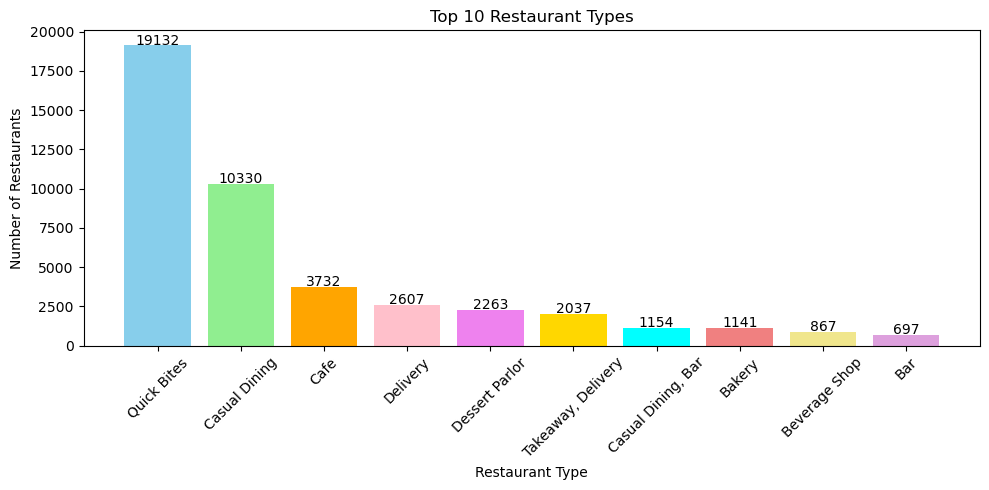

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("zomato.csv")

rest_type_count = df['rest_type'].value_counts().head(10)

plt.figure(figsize=(10,5))

colors = ['skyblue', 'lightgreen', 'orange', 'pink', 'violet',
          'gold', 'cyan', 'lightcoral', 'khaki', 'plum']

plt.bar(rest_type_count.index,
        rest_type_count.values,
        color=colors)

plt.title('Top 10 Restaurant Types')
plt.xlabel('Restaurant Type')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45)

for i, v in enumerate(rest_type_count.values):
    plt.text(i, v + 50, str(v), ha='center')

plt.tight_layout()
plt.show()

## Restaurant Distribution by Location

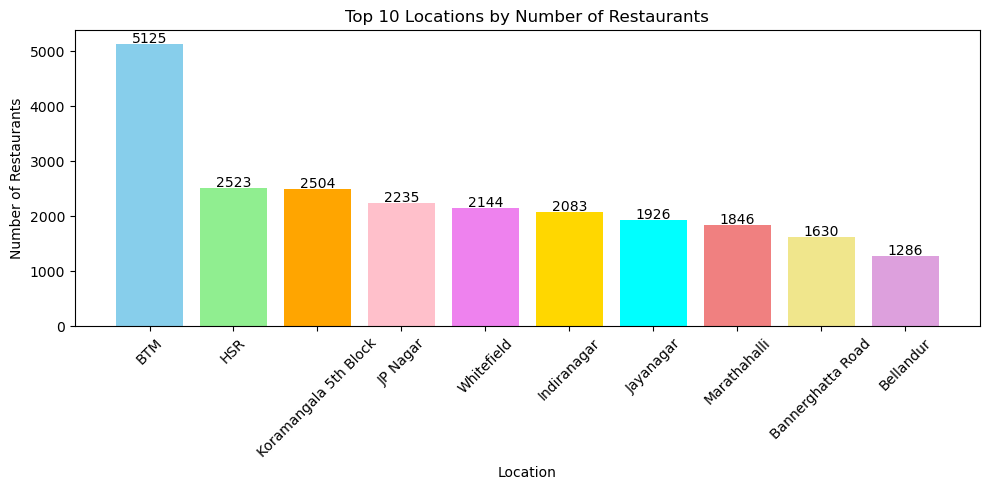

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("zomato.csv")


location_count = df['location'].value_counts().head(10)

plt.figure(figsize=(10,5))

colors = ['skyblue', 'lightgreen', 'orange', 'pink', 'violet',
          'gold', 'cyan', 'lightcoral', 'khaki', 'plum']

plt.bar(location_count.index,
        location_count.values,
        color=colors)

plt.title('Top 10 Locations by Number of Restaurants')
plt.xlabel('Location')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45)

for i, v in enumerate(location_count.values):
    plt.text(i, v + 20, str(v), ha='center')

plt.tight_layout()
plt.show()

## Correlation Heatmap Analysis

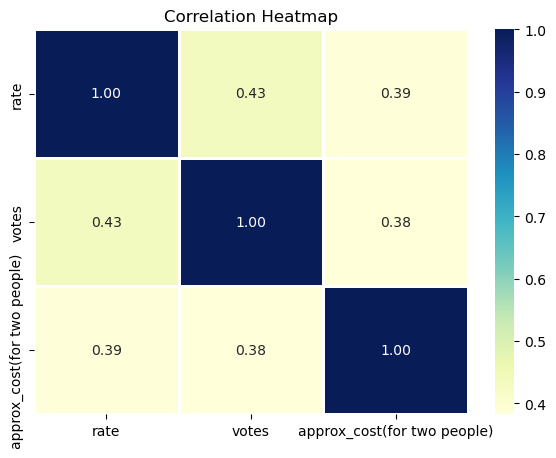

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("zomato.csv")

df['rate'] = df['rate'].astype(str).str.split('/').str[0]
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '', regex=False)
)
df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)


df['votes'] = pd.to_numeric(df['votes'], errors='coerce')


corr_matrix = df[['rate', 'votes', 'approx_cost(for two people)']].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='YlGnBu',      
    fmt='.2f',
    linewidths=1,
    linecolor='white'
)

plt.title('Correlation Heatmap')
plt.show()

## Calculate average rating by table booking

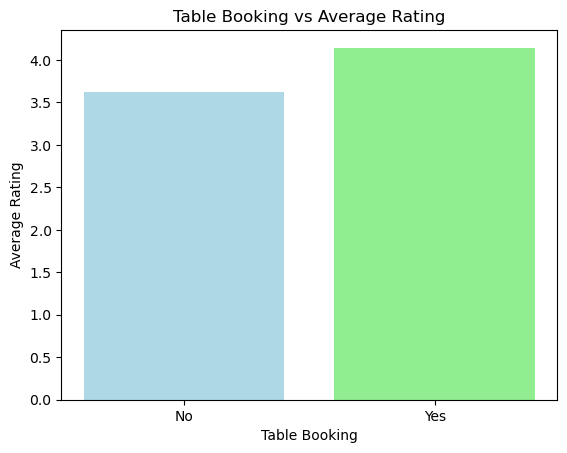

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("zomato.csv")

df['rate'] = df['rate'].astype(str).str.split('/').str[0]
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

booking_rating = df.groupby('book_table')['rate'].mean().dropna()

plt.bar(
    booking_rating.index,
    booking_rating.values,
    color=['lightblue', 'lightgreen']
)

plt.title('Table Booking vs Average Rating')
plt.xlabel('Table Booking')
plt.ylabel('Average Rating')
plt.show()

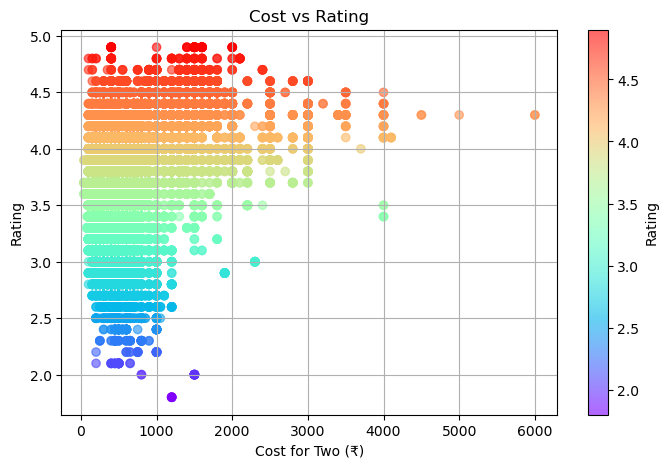

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("zomato.csv")

df['rate'] = df['rate'].astype(str).str.split('/').str[0]
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)

data = df[['approx_cost(for two people)', 'rate']].dropna()

plt.figure(figsize=(8,5))

scatter = plt.scatter(
    data['approx_cost(for two people)'],
    data['rate'],
    c=data['rate'],
    cmap='rainbow',
    alpha=0.6
)

plt.colorbar(scatter, label='Rating')
plt.title('Cost vs Rating')
plt.xlabel('Cost for Two (₹)')
plt.ylabel('Rating')
plt.grid(True)

plt.show()